# **Temperature Data Forescasting: Statistical Decomposition and LSTM**
### **FINAL PROJECT GROUP 3**

1. Shabrina Nur Ihsani
2. Nailah Azzahra
3. Kayla Kirani Kusnadi

Edited note: Refined version by Shabrina Nur Ihsani

# **Import Library and Read Data**

In [1]:
# Import Library Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Membaca Datasets Mentah
data = pd.read_csv('data.csv')
data

,Tanggal,Temperatur rata-rata (°C)
0,1/1/2019,26.0
1,1/2/2019,28.3
2,1/3/2019,28.3
3,1/4/2019,29.3
4,1/5/2019,28.9
...,...,...
1942,4/26/2024,30.2
1943,4/27/2024,29.5
1944,4/28/2024,30.2
1945,4/29/2024,31.3


# **Exploratory Data Analysis**

## Cleaning

In [3]:
# Print Data
data.head()

,Tanggal,Temperatur rata-rata (°C)
0,1/1/2019,26.0
1,1/2/2019,28.3
2,1/3/2019,28.3
3,1/4/2019,29.3
4,1/5/2019,28.9


In [4]:
# Cek Null
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1947 entries, 0 to 1946
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Tanggal                    1947 non-null   object 
 1   Temperatur rata-rata (°C)  1947 non-null   float64
dtypes: float64(1), object(1)
memory usage: 30.6+ KB


## EDA

In [5]:
# Pemisahan kolom

# Split Kolom Tanggal
data[['Month','Day','Year']] = data['Tanggal'].str.split('/', expand=True)

# Print data
data

,Tanggal,Temperatur rata-rata (°C),Month,Day,Year
0,1/1/2019,26.0,1,1,2019
1,1/2/2019,28.3,1,2,2019
2,1/3/2019,28.3,1,3,2019
3,1/4/2019,29.3,1,4,2019
4,1/5/2019,28.9,1,5,2019
...,...,...,...,...,...
1942,4/26/2024,30.2,4,26,2024
1943,4/27/2024,29.5,4,27,2024
1944,4/28/2024,30.2,4,28,2024
1945,4/29/2024,31.3,4,29,2024


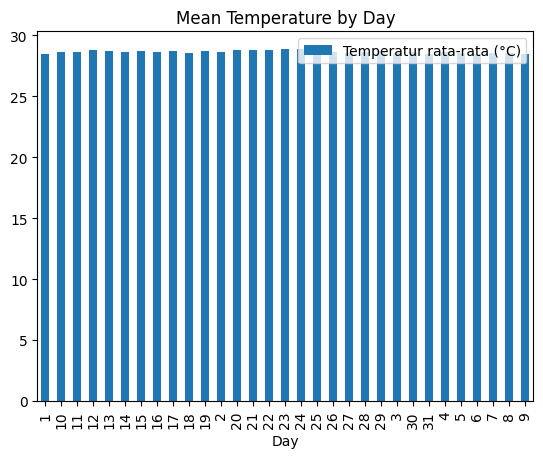

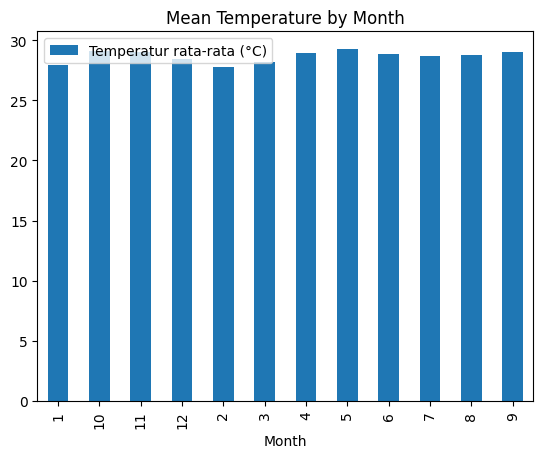

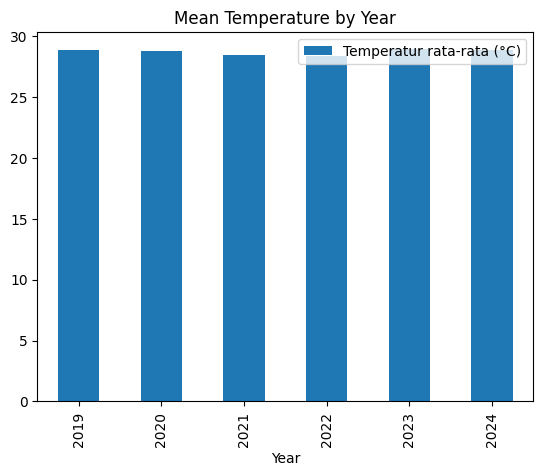

In [6]:
# EDA
cat_cols = ['Day', 'Month', 'Year']

for col in cat_cols:
    data[['Temperatur rata-rata (°C)', col]].groupby(col).mean().plot.bar()
    plt.title(f'Mean Temperature by {col}')
    plt.show()

In [7]:
cat_cols = ['Day', 'Month', 'Year']

for col in cat_cols:
    mean_temps = data[['Temperatur rata-rata (°C)', col]].groupby(col).mean()
    print(f'Rata-rata Temperature by {col}:')
    print(mean_temps)
    print('\n')

Rata-rata Temperature by Day:
     Temperatur rata-rata (°C)
Day                           
1                    28.442187
10                   28.628125
11                   28.645312
12                   28.760938
13                   28.717188
14                   28.614062
15                   28.710938
16                   28.662500
17                   28.678125
18                   28.535937
19                   28.704687
2                    28.587500
20                   28.820312
21                   28.756250
22                   28.787500
23                   28.862500
24                   28.875000
25                   28.523438
26                   28.643750
27                   28.562500
28                   28.617188
29                   28.685000
3                    28.521875
30                   28.622414
31                   28.483784
4                    28.623438
5                    28.557813
6                    28.421875
7                    28.545313
8        

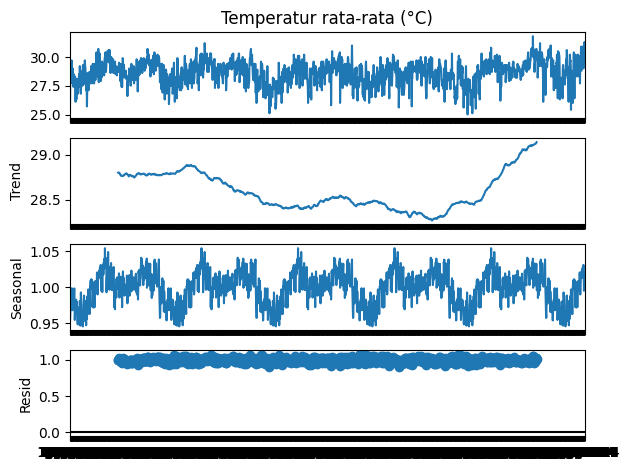

In [8]:
# Mencari Pola Seasonal
from statsmodels.tsa.seasonal import seasonal_decompose
ts = data.set_index('Tanggal')['Temperatur rata-rata (°C)'] + 0.01
result = seasonal_decompose(ts, model='multiplicative', period=365)
result.plot()
plt.show()

In [9]:
# Drop kolom non angka
data.drop(columns = ['Tanggal', 'Day', 'Month', 'Year'], inplace=True)

In [10]:
# Cek Null
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1947 entries, 0 to 1946
Data columns (total 1 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperatur rata-rata (°C)  1947 non-null   float64
dtypes: float64(1)
memory usage: 15.3 KB


array([<Axes: >], dtype=object)

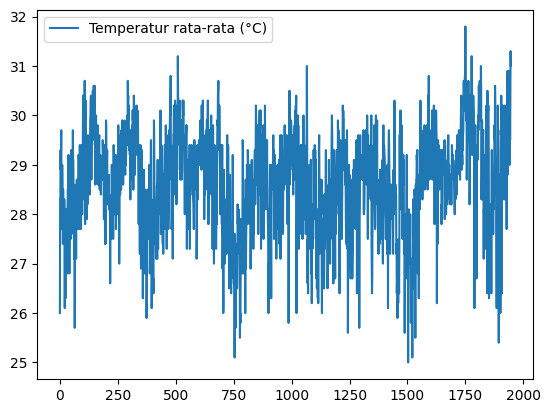

In [11]:
# Plot
data.plot(subplots = True)

In [12]:
# Describe
data.describe()

,Temperatur rata-rata (°C)
count,1947.000000
mean,28.636107
std,1.010950
min,25.000000
25%,28.000000
50%,28.700000
75%,29.300000
max,31.800000


## Pre-Processing

In [13]:
# Import Library
from sklearn.preprocessing import MinMaxScaler #to normalize
from sklearn.model_selection import train_test_split #to train-test split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator #to create sliding window

In [14]:
# Mengubah Kolom Index
data = pd.read_csv('data.csv', parse_dates = ['Tanggal'], index_col= 'Tanggal')
data.head()

,Temperatur rata-rata (°C)
Tanggal,
2019-01-01,26.0
2019-01-02,28.3
2019-01-03,28.3
2019-01-04,29.3
2019-01-05,28.9


In [15]:
# Split the data into train and test sets
def train_test_split(data, train_ratio):
    train_size = int(len(data) * train_ratio)
    train, test = data[:train_size], data[train_size:]
    return train, test

# List of scenarios
scenarios = [0.8, 0.7, 0.6]

# **Decomposition**

### Deseasonalized

In [16]:
def deseasonalize_data(data, train_ratio, seasonal_periods=365):
    # Split the data
    train, test = train_test_split(data, train_ratio)

    # Decompose the training data
    result_train = seasonal_decompose(train, model='multiplicative', period=seasonal_periods)

    # Remove seasonality from training data
    train_desesonalized = train / result_train.seasonal

    # Remove seasonality from test data
    # Assume that the seasonal component for test data is the same as the last observed seasonal component from train data
    test_seasonal_component = result_train.seasonal[-seasonal_periods:].values
    test_seasonal_component = np.tile(test_seasonal_component, int(np.ceil(len(test) / seasonal_periods)))[:len(test)]
    test_seasonal_component = pd.Series(test_seasonal_component, index=test.index)
    test_desesonalized = test / test_seasonal_component

    return train, test, train_desesonalized, test_desesonalized, result_train, test_seasonal_component


In [17]:
def plot_data(train, test, train_desesonalized, test_desesonalized, result, train_ratio):
    # Plot decomposed components
    result.plot()
    plt.suptitle(f'Decomposition of Training Data (Train Ratio = {train_ratio})', y=1.02)
    plt.show()

    # Combine train and test data for plotting
    combined_data = pd.concat([train, test])
    combined_desesonalized = pd.concat([train_desesonalized, test_desesonalized])

    # Plotting original and desesonalized combined data
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data.index, combined_data, label='Original Data')
    plt.plot(combined_data.index, combined_desesonalized, label='Desesonalized Data')
    plt.axvline(train.index[-1], color='gray', linestyle='--', label='Train-Test Split')
    plt.legend()
    plt.title(f'Original vs Desesonalized Data (Train Ratio = {train_ratio})')
    plt.show()


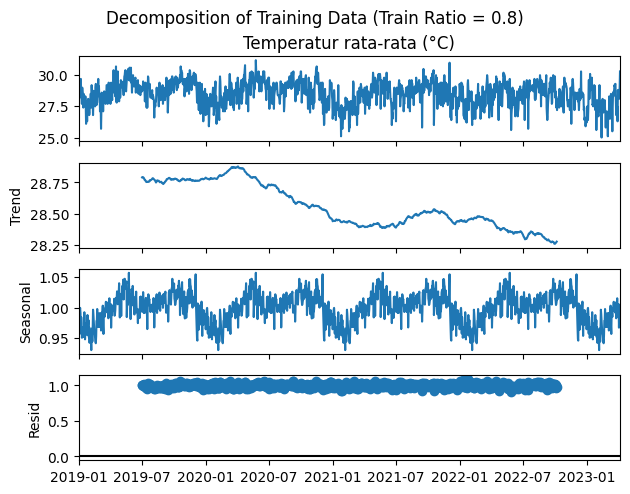

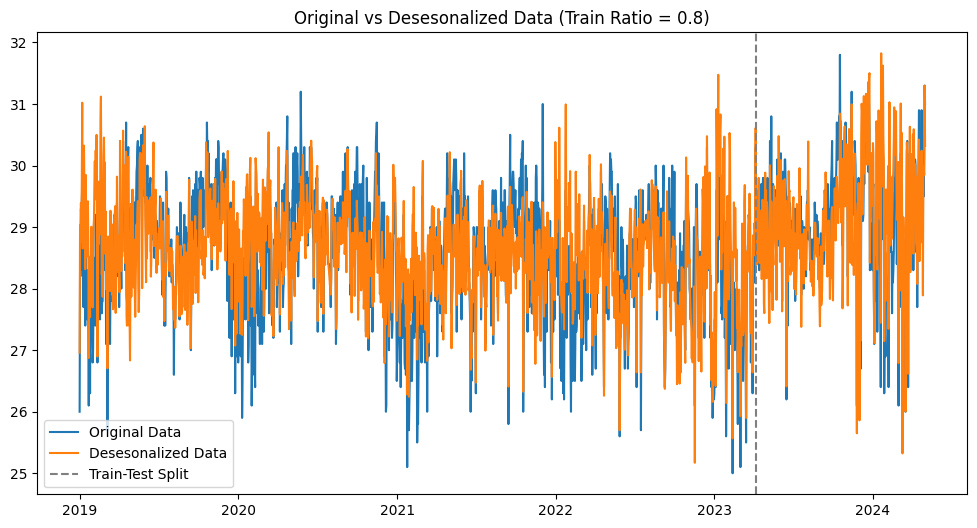

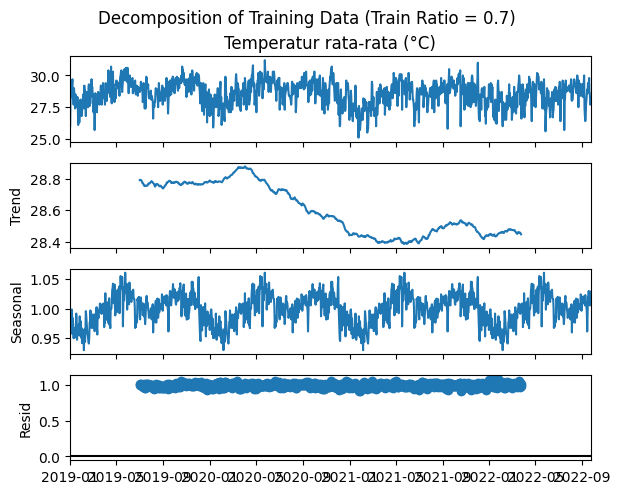

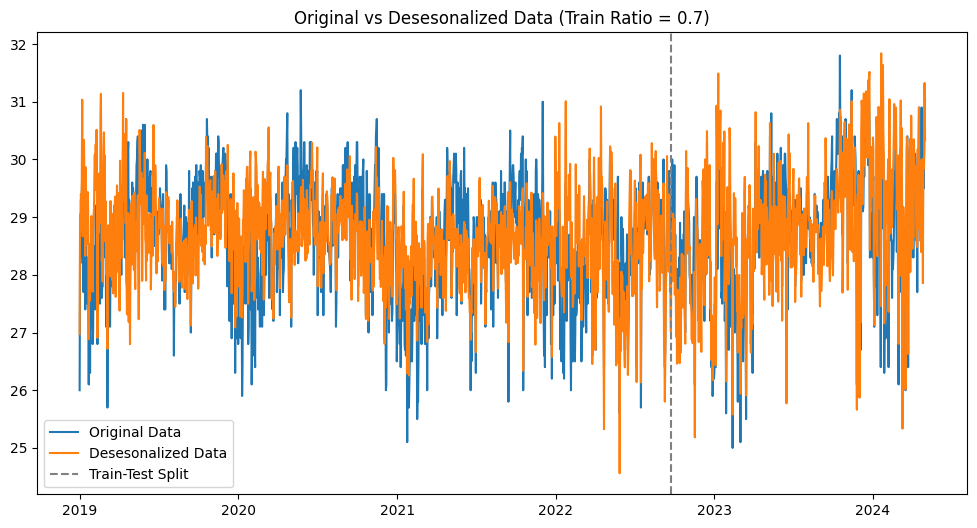

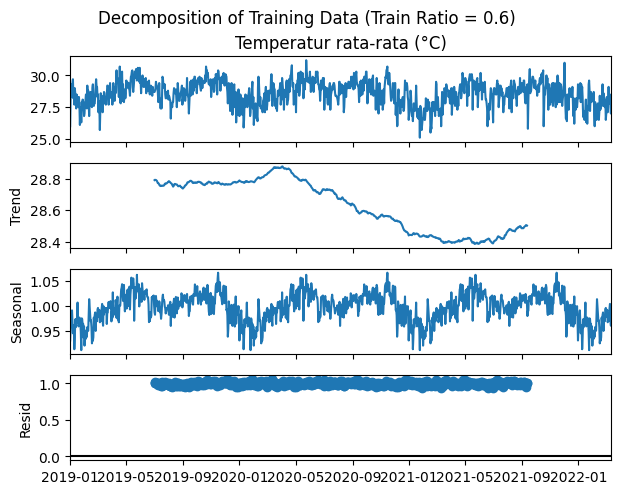

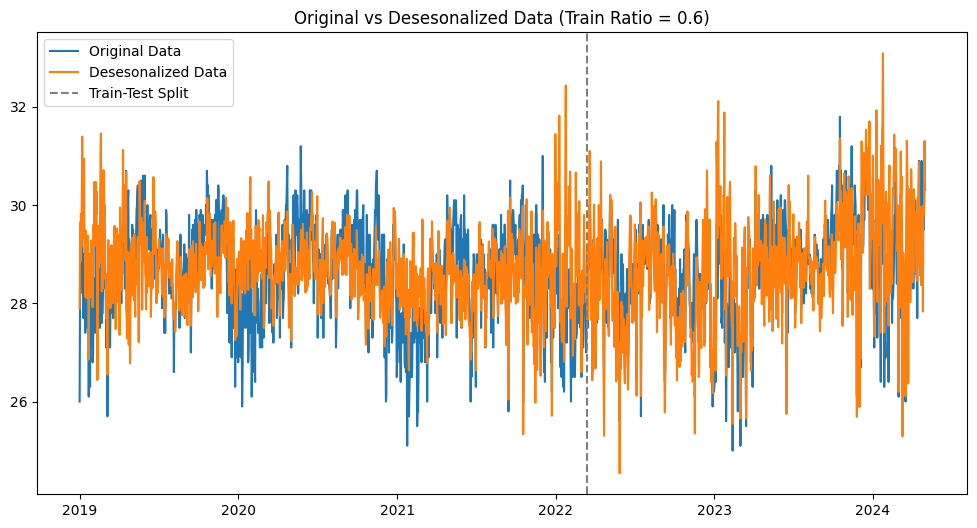

In [18]:
# Result dictionary
results = {}

for scenario in scenarios:
    train, test, train_desesonalized, test_desesonalized, result_train, test_seasonal_component = deseasonalize_data(data['Temperatur rata-rata (°C)'], scenario)

    # Put the result into dictionary
    results[f'train_{scenario}'] = train
    results[f'test_{scenario}'] = test
    results[f'train_desesonalized_{scenario}'] = train_desesonalized
    results[f'test_desesonalized_{scenario}'] = test_desesonalized
    results[f'result_train_{scenario}'] = result_train
    results[f'test_seasonal_component_{scenario}'] = test_seasonal_component

    # Plotting
    plot_data(train, test, train_desesonalized, test_desesonalized, result_train, scenario)

# **LSTM**

### Pre-Processing

In [19]:
scaled_data = {}
scalers = {}

for split in scenarios:
    train_deses = results[f'train_desesonalized_{split}']
    test_deses = results[f'test_desesonalized_{split}']
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    train_scaled = scaler.fit_transform(train_deses.values.reshape(-1, 1))
    test_scaled = scaler.transform(test_deses.values.reshape(-1, 1))

    scaled_data[f'train_scaled_{split}'] = train_scaled
    scaled_data[f'test_scaled_{split}'] = test_scaled
    
    scalers[f'scaler_{split}'] = scaler

In [20]:
# Preparing dataset for LSTM
def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        Y.append(data[i + look_back, 0])
    return np.array(X), np.array(Y)

In [21]:
look_back = 30

model_data = {}

for split in scenarios:
    
    train_scaled = scaled_data[f'train_scaled_{split}']
    test_scaled = scaled_data[f'test_scaled_{split}']
    
    X_train, Y_train = create_dataset(train_scaled, look_back)
    X_test, Y_test = create_dataset(test_scaled, look_back)
    
    # Reshape input to be [samples, time steps, features] for the LSTM
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    # Save the finalized arrays into dictionary
    model_data[f'X_train_{split}'] = X_train
    model_data[f'Y_train_{split}'] = Y_train
    model_data[f'X_test_{split}'] = X_test
    model_data[f'Y_test_{split}'] = Y_test

### Training

In [22]:
# Building model
def build_lstm_model(look_back):
    model = Sequential()
    model.add(LSTM(50, input_shape=(look_back, 1)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [23]:
trained_models = {}
training_histories = {}


for split in scenarios:
    print(f"Training Model for Split {split}")
    
    X_train = model_data[f'X_train_{split}']
    Y_train = model_data[f'Y_train_{split}']
    X_test = model_data[f'X_test_{split}']
    Y_test = model_data[f'Y_test_{split}']
    
    model = build_lstm_model(look_back)
    
    # Train the model
    history = model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=1, 
        validation_data=(X_test, Y_test), 
        verbose=2, 
        shuffle=False
    )
    
    # Save the cleanly trained model and history to the dictionary
    trained_models[f'model_{split}'] = model
    training_histories[f'history_{split}'] = history

Training Model for Split 0.8
Epoch 1/50
1527/1527 - 20s - 13ms/step - loss: 0.0150 - val_loss: 0.0267
Epoch 2/50
1527/1527 - 16s - 10ms/step - loss: 0.0123 - val_loss: 0.0290
Epoch 3/50
1527/1527 - 12s - 8ms/step - loss: 0.0119 - val_loss: 0.0337
Epoch 4/50
1527/1527 - 11s - 7ms/step - loss: 0.0118 - val_loss: 0.0353
Epoch 5/50
1527/1527 - 11s - 7ms/step - loss: 0.0118 - val_loss: 0.0342
Epoch 6/50
1527/1527 - 12s - 8ms/step - loss: 0.0118 - val_loss: 0.0343
Epoch 7/50
1527/1527 - 11s - 7ms/step - loss: 0.0118 - val_loss: 0.0312
Epoch 8/50
1527/1527 - 11s - 7ms/step - loss: 0.0117 - val_loss: 0.0350
Epoch 9/50
1527/1527 - 20s - 13ms/step - loss: 0.0117 - val_loss: 0.0359
Epoch 10/50
1527/1527 - 11s - 7ms/step - loss: 0.0117 - val_loss: 0.0368
Epoch 11/50
1527/1527 - 11s - 7ms/step - loss: 0.0117 - val_loss: 0.0366
Epoch 12/50
1527/1527 - 19s - 13ms/step - loss: 0.0117 - val_loss: 0.0358
Epoch 13/50
1527/1527 - 10s - 7ms/step - loss: 0.0117 - val_loss: 0.0343
Epoch 14/50
1527/1527 - 10s

### Testing

In [24]:
def generate_predictions(model, scaler, X_train, X_test, Y_train, Y_test):

    train_predict = model.predict(X_train, verbose=0)
    test_predict = model.predict(X_test, verbose=0)
    
    # Inverse transform predictions
    train_predict_inv = scaler.inverse_transform(train_predict)
    test_predict_inv = scaler.inverse_transform(test_predict)
    
    # Inverse transform actual Y values (reshaping 1D arrays for the scaler)
    Y_train_inv = scaler.inverse_transform(Y_train.reshape(-1, 1))
    Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))
    
    return train_predict_inv, test_predict_inv, Y_train_inv, Y_test_inv

In [25]:
inversed_results = {}

print("Generating and rescaling predictions for all scenarios")

for split in scenarios:
    
    model = trained_models[f'model_{split}']
    scaler = scalers[f'scaler_{split}']
    
    X_train = model_data[f'X_train_{split}']
    X_test = model_data[f'X_test_{split}']
    Y_train = model_data[f'Y_train_{split}']
    Y_test = model_data[f'Y_test_{split}']
 
    train_pred_inv, test_pred_inv, Y_train_inv, Y_test_inv = generate_predictions(
        model, scaler, X_train, X_test, Y_train, Y_test
    )
    
    inversed_results[f'train_predict_inv_{split}'] = train_pred_inv
    inversed_results[f'test_predict_inv_{split}'] = test_pred_inv
    inversed_results[f'Y_train_inv_{split}'] = Y_train_inv
    inversed_results[f'Y_test_inv_{split}'] = Y_test_inv

Generating and rescaling predictions for all scenarios


### Evaluation

In [26]:
# Import Library
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import pandas as pd

In [27]:
def calculate_metrics(Y_true, Y_pred):

    Y_true_flat = Y_true.flatten()
    Y_pred_flat = Y_pred.flatten()
    
    mse = mean_squared_error(Y_true_flat, Y_pred_flat)
    mae = mean_absolute_error(Y_true_flat, Y_pred_flat)
    mape = mean_absolute_percentage_error(Y_true_flat, Y_pred_flat)
    
    return mse, mae, mape

In [28]:
# Rescaling Predictions
rescaled_predictions = {}

for split in scenarios:
    result_train = results[f'result_train_{split}']
    test_seasonal_comp = results[f'test_seasonal_component_{split}']
    
    train_predict_inv = inversed_results[f'train_predict_inv_{split}']
    test_predict_inv = inversed_results[f'test_predict_inv_{split}']
    
    train_data = results[f'train_{split}']
    test_data = results[f'test_{split}']
    
    # Multiply by the seasonal components to reconstruct the actual weather
    train_rescaled = train_predict_inv.flatten() * result_train.seasonal[look_back : len(train_predict_inv) + look_back].values
    test_rescaled = test_predict_inv.flatten() * test_seasonal_comp[look_back : len(test_predict_inv) + look_back].values

    rescaled_predictions[f'train_rescaled_{split}'] = train_rescaled
    rescaled_predictions[f'test_rescaled_{split}'] = test_rescaled

In [29]:
# Evaluation Metrics
evaluation_results = []

for split in scenarios:
    
    train_predict = rescaled_predictions[f'train_rescaled_{split}']
    test_predict = rescaled_predictions[f'test_rescaled_{split}']
    
    train_data = results[f'train_{split}']
    test_data = results[f'test_{split}']
    Y_train = train_data.iloc[look_back:].values
    Y_test = test_data.iloc[look_back:].values
    
    tr_mse, tr_mae, tr_mape = calculate_metrics(Y_train, train_predict)
    ts_mse, ts_mae, ts_mape = calculate_metrics(Y_test, test_predict)

    evaluation_results.append({
        'Scenario': f'{int(float(split)*100)}/{100 - int(float(split)*100)}',
        'Train MSE': round(tr_mse, 4),
        'Test MSE': round(ts_mse, 4),
        'Train MAE': round(tr_mae, 4),
        'Test MAE': round(ts_mae, 4),
        'Train MAPE': round(tr_mape, 4),
        'Test MAPE': round(ts_mape, 4)
    })

# Convert to a clean DataFrame and display
df_metrics = pd.DataFrame(evaluation_results)
df_metrics.set_index('Scenario', inplace=True)

print("\n--- Final Evaluation Metrics ---")
display(df_metrics)


--- Final Evaluation Metrics ---


,Train MSE,Test MSE,Train MAE,Test MAE,Train MAPE,Test MAPE
Scenario,,,,,,
80/20,0.5121,1.1641,0.5677,0.8653,0.0199,0.0296
70/30,0.4487,0.9648,0.5141,0.7676,0.0180,0.0267
60/40,0.4557,1.1529,0.5148,0.8312,0.0181,0.0291


### Plotting

In [30]:
def plot_scenario_forecast(data, train_data, test_data, train_predict, test_predict, 
                           split, look_back, future_dates=None, 
                           future_predict_train=None, future_predict_full=None):

    plt.figure(figsize=(14, 7))
    
    plt.plot(data.index, data['Temperatur rata-rata (°C)'], color='grey', label='Data Asli (Ground Truth)', alpha=0.5)
    
    plt.plot(train_data.index[look_back:], train_predict, color='blueviolet', label='Prediksi Train', linewidth=1.5)
    plt.plot(test_data.index[look_back:], test_predict, color='cornflowerblue', label='Prediksi Test', linewidth=1.5)
    
    plt.axvline(train_data.index[-1], color='gray', linestyle='--', label='Batas Train/Test', alpha=0.7)

    if future_dates is not None:
        # Approach A: Training Baseline Seasonality
        if future_predict_train is not None:
            plt.plot(future_dates, future_predict_train, color='darkorange', 
                     label='Masa Depan (Pendekatan A: Musiman Train)', 
                     linewidth=2, linestyle='--')
        
        # Approach B: Full Timeline Seasonality
        if future_predict_full is not None:
            plt.plot(future_dates, future_predict_full, color='navy', 
                     label='Masa Depan (Pendekatan B: Musiman Penuh 3 Tahun)', 
                     linewidth=2.5)

    train_ratio = int(float(split) * 100)
    test_ratio = 100 - train_ratio
    plt.title(f'Hasil Perbandingan Forecasting Suhu: Skenario Split {train_ratio}/{test_ratio}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Tanggal', fontsize=12, labelpad=10)
    plt.ylabel('Temperatur rata-rata (°C)', fontsize=12, labelpad=10)
    plt.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

### Forecasting

In [31]:
def generate_future_forecast(model, initial_input, forecast_periods, look_back):
    
    forecast_raw = []
    current_input = initial_input.copy()
    
    for _ in range(forecast_periods):

        reshaped_input = np.reshape(current_input, (1, look_back, 1))

        predicted_val = model.predict(reshaped_input, verbose=0)
        forecast_raw.append(predicted_val[0, 0])

        current_input = np.append(current_input[1:], predicted_val, axis=0)
        
    return np.array(forecast_raw).reshape(-1, 1)

In [32]:
def reverse_scaling_and_seasonality(forecast_raw, scaler, train_seasonal_data, forecast_periods, seasonal_periods=365):

    # Inverse Transform back to original scale
    forecast_inv = scaler.inverse_transform(forecast_raw).flatten()

    future_seasonal_comp = np.tile(
        train_seasonal_data[-seasonal_periods:], 
        int(np.ceil(forecast_periods / seasonal_periods))
    )[:forecast_periods]
    
    # Re-seasonalize the data
    forecast_rescaled = forecast_inv * future_seasonal_comp
    
    return forecast_rescaled

In [33]:
forecast_periods = 365
final_future_forecasts = {}

print(f"Generating {forecast_periods}-day forecasts for all scenarios")

full_decomposition = seasonal_decompose(data['Temperatur rata-rata (°C)'] + 0.01, model='multiplicative', period=365)

for split in scenarios:
    
    model = trained_models[f'model_{split}']
    scaler = scalers[f'scaler_{split}']
    test_scaled = scaled_data[f'test_scaled_{split}']
    result_train = results[f'result_train_{split}']
    
    initial_input = test_scaled[-look_back:]
    
    forecast_raw = generate_future_forecast(model, initial_input, forecast_periods, look_back)
    
    # APPROACH A: Using the seasonal decomposition from the training dataset
    forecast_rescaled_train = reverse_scaling_and_seasonality(
        forecast_raw, scaler, result_train.seasonal.values, forecast_periods
    )
    
    final_future_forecasts[f'forecast_{split}_train_season'] = forecast_rescaled_train
    
    # APPROACH B: Using the full seasonal decomposition from the entire dataset
    forecast_rescaled_full = reverse_scaling_and_seasonality(
        forecast_raw, scaler, full_decomposition.seasonal.values, forecast_periods
    )
    
    final_future_forecasts[f'forecast_{split}_full_season'] = forecast_rescaled_full

last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=forecast_periods + 1, inclusive='right')

Generating 365-day forecasts for all scenarios


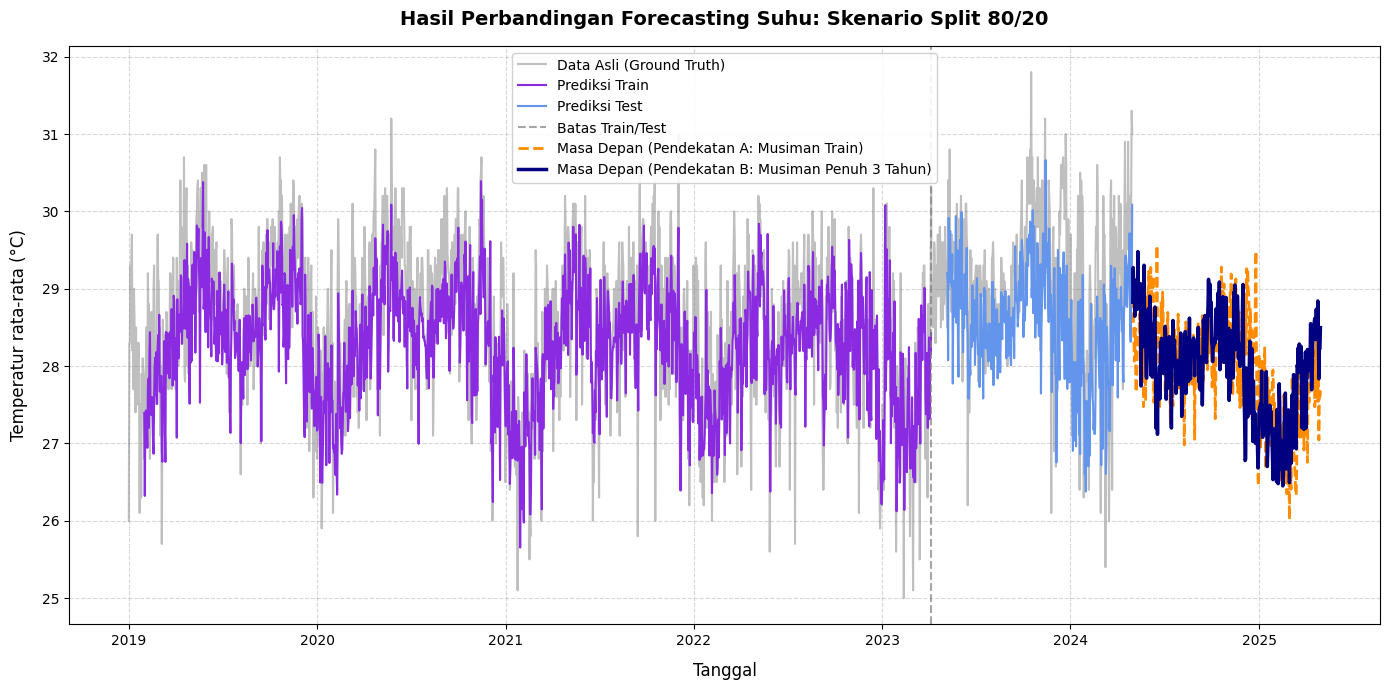

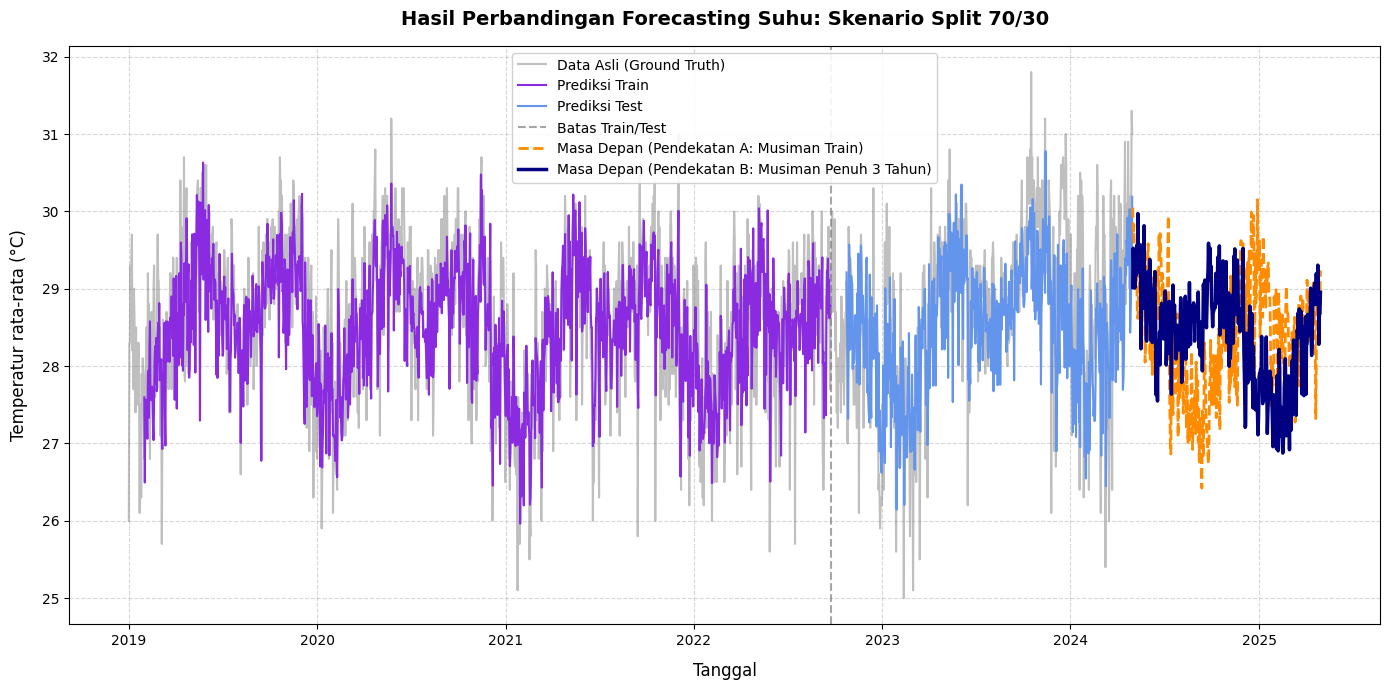

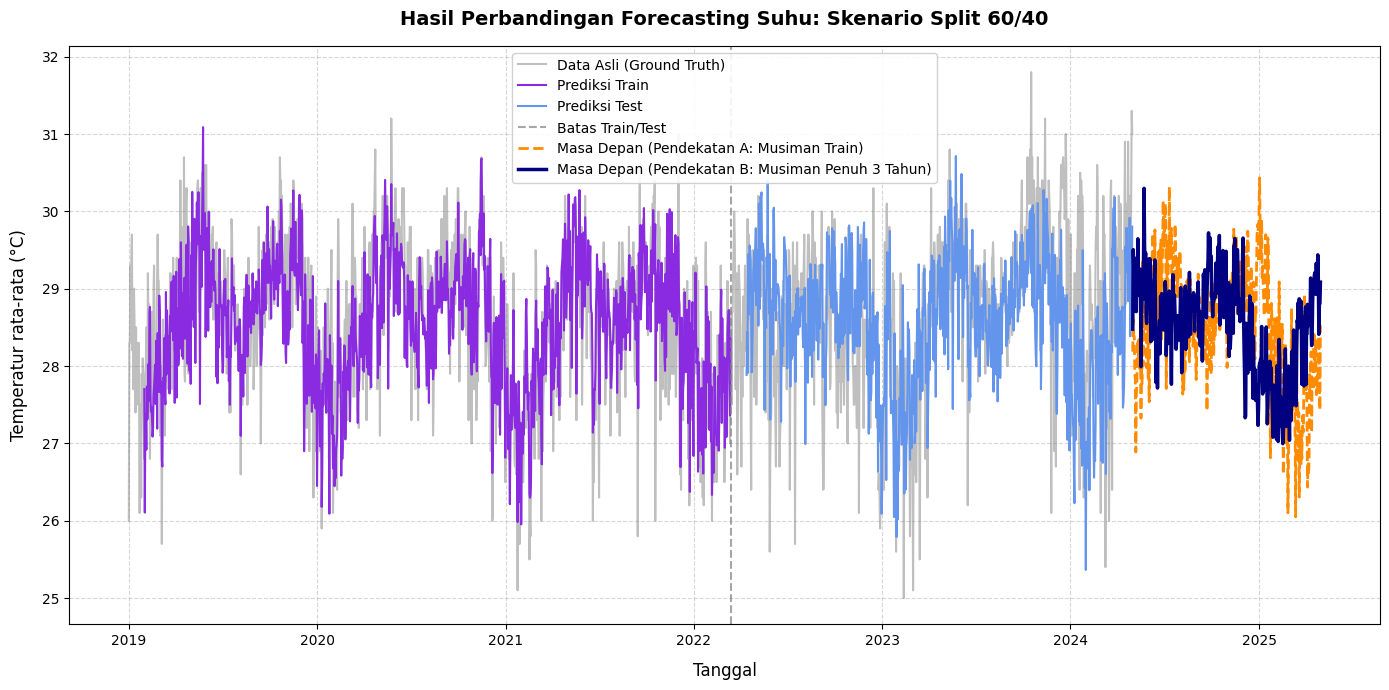

In [34]:
# Plotting
for split in scenarios:
    train_data = results[f'train_{split}']
    test_data = results[f'test_{split}']

    train_predict = rescaled_predictions[f'train_rescaled_{split}']
    test_predict = rescaled_predictions[f'test_rescaled_{split}']
    
    future_train = final_future_forecasts.get(f'forecast_{split}_train_season')
    future_full = final_future_forecasts.get(f'forecast_{split}_full_season')
    
    plot_scenario_forecast(
        data=data, 
        train_data=train_data, 
        test_data=test_data, 
        train_predict=train_predict, 
        test_predict=test_predict, 
        split=split, 
        look_back=look_back,
        future_dates=future_dates,
        future_predict_train=future_train, 
        future_predict_full=future_full     
    )